# Máquinas Térmicas - Lección 10
## Plantas de Turbina de Gas (Ciclo Brayton) y Motores a Reacción

**Autor:** Camilo Bayona
**Fecha:** 07/10/25

### Objetivos de aprendizaje

Al finalizar esta lección, el estudiante será capaz de:

- Identificar **tipos de motores aeronáuticos** y **turbinas de gas** y sus aplicaciones.
- Describir el **ciclo Brayton** y relacionarlo con los componentes: **compresor–cámara de combustión–turbina–tobera-ejes**.
- Formular **modelos térmicos y de fluidos** básicos para estimar **rendimiento** y **empuje**.
- Diferenciar **eficiencia térmica**, **propulsiva** y **global**; discutir estrategias de mejora.
- Aplicar la **ecuación de empuje** (enfoque de caja negra) a casos simples.

In [1]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "matplotlib", "ipywidgets", "numpy", "scipy", "CoolProp"], check=True)

In [2]:
# === Setup =================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Circle, Wedge, FancyBboxPatch
from ipywidgets import (interact, interactive_output, FloatSlider, IntSlider,
                        Dropdown, Checkbox, Play, HBox, VBox, jslink)
from IPython.display import display
from CoolProp.CoolProp import PropsSI

g0 = 9.80665  # m/s^2
P_atm, T_atm = 101325.0, 288.15  # Pa, K (ISA nivel del mar)

# Paleta del proyecto (misma que Lecciones 7-10/10b; roles nuevos de esta lección)
COL = {"aire": "#2a78d6", "abierta": "#1baf7a", "cerrada": "#8a8a86", "perdida": "#e34948",
       "combustion": "#eb6834", "metal": "#c3c2b7", "tinta": "#3a3a38",
       "compresor": "#2a78d6", "turbina": "#4a3aa7", "tobera": "#c3c2b7",
       "eje": "#8a8a86", "helice": "#1baf7a"}

print("Setup OK")

Setup OK


##1. Motores de Turbina de Gas (Brayton)

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/8/8b/GE_H_series_Gas_Turbine.jpg)

Una turbina de gas es un motor de combustión interna que convierte energía térmica en energía mecánica. A diferencia de un motor de pistón, donde la combustión es intermitente, en una turbina de gas la combustión es continua.

Se compone principalmente de un compresor, una cámara de combustión y una turbina. Las turbinas de gas se utilizan en plantas de energía eléctrica, barcos, locomotoras y tanques.


- **Componentes principales:**
  - **Compresor:** Aspira y comprime el aire antes de que entre en la cámara de combustión. Puede ser de tipo axial o centrífugo o ambos.
  - **Cámara de combustión:** Aquí es donde el aire comprimido se mezcla con el combustible y se quema. La combustión produce gases calientes a alta presión.
  - **Turbina:** Los gases calientes se expanden a través de la turbina, haciendo que gire. Esta rotación se utiliza para impulsar el compresor y, en algunas aplicaciones, para generar energía mecánica o eléctrica.
  - **Eje:** El o los ejes se encargan de transmitir la rotación y los torques entre los distintos elementos del motor.

- **Aplicaciones:** Las turbinas de gas se utilizan en una variedad de aplicaciones, incluyendo:
  - **Plantas de energía eléctrica:** Para la generación de electricidad.
  - **Barcos:** Como propulsión principal o para generar electricidad a bordo.
  - **Locomotoras:** En trenes de alta velocidad o en lugares donde el suministro de electricidad es un problema.
  - **Tanques:** Algunos tanques modernos utilizan turbinas de gas debido a su alta potencia y menor peso en comparación con los motores diésel.
  - **Aeronaves:** Helicópteros y aviones tienen como motor o motores principales este tipo de turbinas.

> **Nota de alcance de esta actualización.** Todas las arquitecturas de esta lección (§3-§10) son variaciones del mismo ciclo Brayton: compresión → combustión → expansión, cambiando solo qué se hace con la energía que sale de la turbina (eje, hélice, chorro, o nada — ver cohetes). Esa idea se hace explícita con el **Widget 1** justo después de §2, y se cuantifica en §12 con el ciclo Brayton real (CoolProp) y las ecuaciones de empuje y eficiencia. El ciclo Brayton **ideal** ya se estudió a fondo en la **Lección 2** (comparación entre ciclos); aquí se extiende al **ciclo real** con eficiencias isentrópicas de compresor y turbina, y se conecta con la propulsión aeronáutica.

## 2. Tipos de motores de Turbina de Gas

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/7/79/Gas_turbine_applications_%28numbered%29.svg)

### Atlas interactivo de arquitecturas

El widget siguiente dibuja el esquema de flujo de cada arquitectura que se explica en las secciones §3-§10. Todas comparten el mismo lenguaje visual: azul = aire/compresión, naranja = combustión, violeta = turbina, gris = tobera/eje. Úsalo como referencia mientras lees cada sección — vuelve a él cuando quieras comparar dos arquitecturas directamente.

In [3]:
# WIDGET 1 (bandera) — atlas interactivo de arquitecturas de motores Brayton
def segmentos(tipo):
    # (nombre, ancho, color)
    if tipo == "Turboeje":
        return [("Entrada", 0.7, COL["aire"]), ("Compresor", 1.0, COL["compresor"]),
                ("Cámara de\ncombustión", 1.0, COL["combustion"]), ("Turbina\ngeneradora", 1.0, COL["turbina"]),
                ("Turbina\nlibre", 1.0, COL["turbina"]), ("Reductor\n+ eje útil", 1.2, COL["eje"])]
    if tipo == "Turbohélice":
        return [("Entrada", 0.7, COL["aire"]), ("Compresor", 1.0, COL["compresor"]),
                ("Cámara de\ncombustión", 1.0, COL["combustion"]), ("Turbina\ngeneradora", 1.0, COL["turbina"]),
                ("Turbina\nlibre", 1.0, COL["turbina"]), ("Reductor", 0.8, COL["eje"]), ("Hélice", 0.9, COL["helice"])]
    if tipo == "Turbofán":
        return [("Fan", 1.1, COL["helice"]), ("Compresor", 0.9, COL["compresor"]),
                ("Cámara de\ncombustión", 0.9, COL["combustion"]), ("Turbina", 0.9, COL["turbina"]),
                ("Tobera\n(flujo primario)", 1.0, COL["tobera"])]
    if tipo == "Turborreactor":
        return [("Entrada", 0.7, COL["aire"]), ("Compresor", 1.0, COL["compresor"]),
                ("Cámara de\ncombustión", 1.0, COL["combustion"]), ("Turbina", 1.0, COL["turbina"]),
                ("Tobera", 1.0, COL["tobera"])]
    if tipo == "Ramjet":
        return [("Difusor\n(compresión por ariete)", 1.5, COL["aire"]),
                ("Cámara de\ncombustión", 1.3, COL["combustion"]), ("Tobera", 1.2, COL["tobera"])]
    if tipo == "Scramjet":
        return [("Difusor\nsupersónico", 1.5, COL["aire"]),
                ("Combustión\nsupersónica", 1.3, COL["combustion"]), ("Tobera", 1.2, COL["tobera"])]
    if tipo == "Cohete":
        return [("Tanque\ncombustible", 0.8, COL["aire"]), ("Tanque\noxidante", 0.8, COL["metal"]),
                ("Cámara de\ncombustión", 1.0, COL["combustion"]), ("Tobera\nde Laval", 1.2, COL["tobera"])]
    return []

def dibujar_motor(ax, tipo):
    segs = segmentos(tipo)
    x = 0.0
    h = 1.0
    for i, (nombre, w, color) in enumerate(segs):
        y0 = 0.0
        hh = h
        # el "Fan" del turbofán ocupa más altura (simboliza el mayor diámetro)
        if nombre == "Fan":
            hh = 1.6; y0 = -0.3
        # los dos tanques del cohete van en paralelo (mitad de altura cada uno)
        if nombre in ("Tanque\ncombustible", "Tanque\noxidante"):
            hh = 0.45
            y0 = 0.55 if nombre == "Tanque\ncombustible" else 0.0
        ax.add_patch(Rectangle((x, y0), w, hh, fc=color, ec=COL["tinta"], lw=1.3, alpha=0.85, zorder=3))
        ax.text(x + w/2, y0 + hh/2, nombre, ha="center", va="center", fontsize=8.5,
                color="white" if color != COL["metal"] else COL["tinta"], fontweight="bold", zorder=4)
        if nombre not in ("Tanque\ncombustible",):
            x_next = x + w
        else:
            x_next = x  # el tanque de oxidante se dibuja en el mismo rango x que el de combustible
        if nombre != "Tanque\ncombustible":
            x = x_next

    total_w = x
    # flecha de flujo principal por encima de los bloques
    ax.add_patch(FancyArrowPatch((-0.3, 1.25), (total_w + 0.3, 1.25),
                                  arrowstyle="-|>", mutation_scale=14, color=COL["tinta"], lw=1.2))
    if tipo == "Turbofán":
        # ducto de bypass: rodea compresor-combustor-turbina por fuera
        ax.add_patch(FancyArrowPatch((1.1, 1.5), (total_w - 1.0, 1.5),
                                     arrowstyle="-|>", mutation_scale=12, color=COL["aire"], lw=1.6,
                                     connectionstyle="arc3,rad=-0.25"))
        ax.text(total_w/2, 1.95, "flujo de bypass (aire frío)", ha="center", fontsize=7.5,
                color=COL["aire"], style="italic")
    if tipo in ("Ramjet", "Scramjet"):
        ax.text(total_w/2, -0.4, "sin partes móviles (ni compresor ni turbina)", ha="center",
                fontsize=8, style="italic", color=COL["tinta"])
    if tipo == "Cohete":
        ax.text(total_w/2, -0.4, "no requiere aire atmosférico: transporta su propio oxidante",
                ha="center", fontsize=8, style="italic", color=COL["tinta"])

    ax.set_xlim(-0.6, total_w + 0.6); ax.set_ylim(-0.7, 2.2)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{tipo}", fontsize=13, fontweight="bold")

def widget_atlas(tipo="Turborreactor"):
    fig, ax = plt.subplots(figsize=(9, 3.2))
    dibujar_motor(ax, tipo)
    plt.tight_layout(); plt.show()

tipo_dd = Dropdown(options=["Turboeje", "Turbohélice", "Turbofán", "Turborreactor", "Ramjet", "Scramjet", "Cohete"],
                    value="Turborreactor", description="Arquitectura")
out_atlas = interactive_output(widget_atlas, {"tipo": tipo_dd})
display(VBox([tipo_dd, out_atlas]))

## 3.Turboeje (Turboshaft)

El **turboeje** es una arquitectura derivada del **turbojet/turbina de gas**, optimizada para entregar **potencia mecánica al eje** en lugar de generar empuje directo con un chorro de gases.

Se emplea ampliamente en **helicópteros**, **embarcaciones**, **vehículos blindados** y **generadores eléctricos**.

**Principio de funcionamiento:**
- El aire se **aspira y comprime** en el compresor.
- En la **cámara de combustión**, el combustible se mezcla y quema liberando energía térmica.
- Los gases calientes pasan por **turbinas**:
  - Una primera sección acciona el **compresor** (turbina de gas generadora).
  - Una segunda turbina **libre** convierte la energía restante en **potencia de eje útil**, transmitida a un **reductor** y posteriormente al rotor o generador.

**Características:**
- Entrega **alto par** a bajas velocidades de rotación.
- Operación continua, con **respuesta rápida** y **buena relación potencia/peso**.
- Requiere **sistemas de reducción** debido a las altas rpm del eje de la turbina.

**Aplicaciones:**
- **Helicópteros** (Bell, Sikorsky, Eurocopter), **tanques** (como el M1 Abrams), **plataformas navales**, y **plantas de emergencia**.

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/4/42/General_Electric_LM6000.jpg)

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/6/68/MZKT_open_day_2019_p06.jpg)

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/b/ba/AGT1500_engine_and_M1_tank.JPEG)


![Biomasa](https://upload.wikimedia.org/wikipedia/commons/0/06/Gas_turbine_from_MGB_2009.jpg)

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/2/27/ChryslerTurbineEngine01_crop1.jpg)

> Esquema de flujo: selecciona "Turboeje" en el **Widget 1** (§2).

## 4. Turbohélice (Turboprop)

El **turbohélice** combina los principios de la **turbina de gas** y la **propulsión por hélice**, aprovechando la eficiencia del ciclo Brayton en el núcleo del motor, pero transmitiendo la mayor parte de la energía a una **hélice** que genera el empuje.

**Componentes principales:**
- **Compresor**, **cámara de combustión** y **turbina** (núcleo).
- **Turbina de potencia libre** (similar al turboeje) que entrega par al **reductor**.
- **Caja reductora** que disminuye las rpm para accionar la hélice a velocidades subsónicas eficientes.
- **Hélice de paso variable**, que ajusta su ángulo para optimizar el empuje según las condiciones de vuelo.

**Características:**
- Alta **eficiencia propulsiva** a **velocidades moderadas (Mach < 0.6)**.
- Excelente **rendimiento en despegue y ascenso**.
- Menor consumo específico de combustible que los turbofanes en vuelos regionales o de corto alcance.

**Aplicaciones:**
- Aeronaves **regionales** y **de transporte militar** (ej. ATR 72, C-130 Hercules).
- Ideal para vuelos de **corto y mediano alcance**, donde la eficiencia supera al empuje puro del turbojet.

**Comparación con otras arquitecturas:**
- Menor velocidad máxima que el **turbofán**, pero mayor **eficiencia propulsiva** a bajas velocidades.
- Requiere un **sistema de hélice complejo** y un **reductor robusto** para manejar el alto par.



![Biomasa](https://upload.wikimedia.org/wikipedia/commons/d/db/RAFO_EADS_CASA_C-295_901_PAS_2013_04_PW127G_turboprop_engine.jpg)

> Esquema de flujo: selecciona "Turbohélice" en el **Widget 1** (§2). La curva de eficiencia propulsiva vs. velocidad de vuelo (§12d) explica cuantitativamente por qué domina justo en ese régimen de Mach.

> **Para profundizar.** `research_sources/Turboprop Engine/` contiene un proyecto real de este curso: una herramienta computacional en Simulink que simula el comportamiento aerotermodinámico de un turbohélice usando teoría del elemento de pala (*Blade Element Momentum Theory*, BEMT), validada contra datos reales de motores tipo PT6/ATR. Sus propios autores la plantean como soporte para mantenimiento, manufactura y reconversión energética a nivel nacional — un ejemplo de hasta dónde puede llegar un proyecto de este curso.

## 5. Turboventilados (Turbofan)

El turbofán combina las características de un turbojet con un ventilador (fan) de gran diámetro en la entrada. Este ventilador produce un flujo de aire que rodea el flujo hacia el ciclo del motor, generando empuje adicional.

- **Componentes principales:**
  - **Ventilador (Fan):** Situado al frente del motor, aspira aire adicional, parte del cual pasa por el motor (flujo primario) y parte rodea el motor (flujo secundario o bypass).
  - **Compresor, cámara de combustión y turbina:** Funcionan de manera similar al turbojet.
  - **Tobera:** Expulsa los gases de escape y el flujo de aire de bypass, generando empuje.

- **Aplicaciones:** Los motores a reacción son esenciales en la aviación. Se utilizan escencialmente en la mayoría de los aviones comerciales y militares: aviones de mediana y larga distancia.

- **Ventajas:**
  - Mayor eficiencia a velocidades subsónicas en comparación con los turbojets, lo que los hace ideales para aviones comerciales.
  - Menor ruido debido al flujo de aire de bypass que envuelve y amortigua el ruido del flujo principal.

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/1/18/D%C3%BCsseldorf%2C_Flughafen%2C_D-ALSD%2C_2011-10_CN-03.jpg)


![Biomasa](https://upload.wikimedia.org/wikipedia/commons/d/d1/Cfm56-3-turbofan.jpeg)

> Esquema de flujo (incluyendo el ducto de bypass): selecciona "Turbofán" en el **Widget 1** (§2) — reemplaza los dos diagramas esquemáticos sueltos del documento original por una versión consistente con el resto del curso.

## 6.Turboreactor (Jet Engine):

Es un tipo de motor que utiliza solo propulsión a chorro para generar empuje. Funciona expulsando un chorro de fluido a alta velocidad para generar una fuerza en dirección opuesta, según la tercera ley de Newton.

En estos motores, el aire es aspirado por el motor, luego es comprimido, mezclado con combustible y quemado. Los gases calientes se expanden y son expulsados a alta velocidad a través de una tobera, generando empuje.

- **Componentes principales:**
  - **Entrada de aire (Intake):** Canaliza el aire hacia el compresor.
  - **Compresor:** Aumenta la presión del aire antes de que entre en la cámara de combustión.
  - **Cámara de combustión:** Donde el aire comprimido se mezcla con el combustible y se quema.
  - **Turbina:** Utiliza la energía de los gases calientes para impulsar el compresor y otros componentes.
  - **Eje:** El o los ejes se encargan de transmitir la rotación y los torques entre los distintos elementos del motor.
  - **Tobera:** Acelera los gases de escape para producir empuje.

- **Aplicaciones:** Los motores a reacción son históricos en la aviación. Se utilizan escencialmente en aviones militares: Cazas, bombarderos y aviones experimentales.

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/5/56/J85_ge_17a_turbojet_engine.jpg)

> Esquema de flujo: selecciona "Turborreactor" en el **Widget 1** (§2) — reemplaza el diagrama esquemático suelto del documento original.

## 7. Estatorreactor (Ramjet)

Un ramjet es un motor a reacción que no tiene partes móviles, como turbinas o compresores. En su lugar, utiliza la velocidad del avión para comprimir el aire entrante antes de la combustión.

- **Componentes principales:**
  - **Difusor:** Ralentiza y comprime el aire entrante.
  - **Cámara de combustión:** Donde el aire comprimido se mezcla con el combustible y se quema.
  - **Tobera:** Acelera los gases de escape para producir empuje.

- **Limitaciones:**
  - No puede operar en parado o a bajas velocidades; necesita una velocidad inicial para funcionar.
  - Generalmente utilizado en aplicaciones de alta velocidad, como misiles.

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/7/73/Leduc_010_Ramjet_Prototype_%2811729010226%29.jpg)

> Esquema de flujo: selecciona "Ramjet" en el **Widget 1** (§2) — reemplaza los dos diagramas esquemáticos sueltos del documento original.

> **Para profundizar.** `research_sources/RAMJET Engine/` contiene un artículo publicado por este grupo de investigación — S. Cadavid Franco y C. Bayona Roa, *"One-Dimensional Numerical Modelling of a Supersonic RAMJET Engine with Parametrizable Geometry"* — con un modelo 1D en MATLAB validado contra literatura (Dallos). Resultados de la condición base: empuje neto **1719.4 N**, impulso específico **2094.6 s**, Mach de salida **2.033**, eficiencia global **30.3 %**. Ese valor de impulso específico se retoma en §10 para compararlo con los motores de cohete.

##8.Supercombustión (Scramjet)

Es una variante del ramjet diseñada para operar a velocidades hipersónicas. A diferencia del ramjet, donde la combustión ocurre a velocidades subsónicas, en un scramjet la combustión ocurre a velocidades supersónicas.

- **Componentes principales:**
  - **Difusor:** Captura el aire entrante y lo dirige hacia la cámara de combustión.
  - **Cámara de combustión:** Donde el aire supersónico se mezcla con el combustible y se quema.
  - **Tobera:** Acelera los gases de escape para producir empuje.

- **Ventajas:**
  - Capaz de operar a velocidades extremadamente altas (Mach 5 y superiores).
  - Potencial para revolucionar el transporte aéreo y espacial en el futuro.

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/4/4a/X43a2_nasa_scramjet.jpg)

> Esquema de flujo: selecciona "Scramjet" en el **Widget 1** (§2) — reemplaza el diagrama esquemático suelto del documento original.

##10. Cohetes (Rockets):

Los **motores de cohete** representan una forma extrema y autosuficiente de motor térmico, en la cual el sistema **transporta su propio comburente y combustible**, eliminando la necesidad de aire atmosférico. Por esta razón, pueden operar **fuera de la atmósfera**, a diferencia de los motores a reacción convencionales.

![Biomasa](https://upload.wikimedia.org/wikipedia/commons/6/67/XLR-99_Rocket_Engine_USAF.jpg)


Aunque no completan el **ciclo Brayton** (ya que carecen de una etapa de compresión ambiental y no existe recirculación de trabajo al compresor), pueden considerarse **parcialmente motores Brayton**, ya que conservan las **etapas de combustión y expansión** como núcleo del proceso.

**Principio de funcionamiento:**
- El **propelente** se almacena en tanques separados:
  - **Combustible:** hidrógeno, queroseno (RP-1), metano u otros hidrocarburos.
  - **Comburente:** oxígeno líquido (LOX), peróxido de nitrógeno o tetróxido de dinitrógeno, entre otros.
- Ambos se **inyectan** en la **cámara de combustión**, donde reaccionan violentamente, generando gases a altísima presión y temperatura.
- Los gases se **expanden** a través de una **tobera convergente-divergente (de Laval)**, alcanzando velocidades **supersónicas** y produciendo el **empuje** mediante la **tercera ley de Newton** (acción–reacción).

**Etapas principales:**
1. **Inyección y mezcla** de propelentes.
2. **Combustión** (alta presión, continua y estable).
3. **Expansión** en la **tobera** para convertir energía térmica en cinética.

> Estas etapas corresponden a las dos últimas fases del ciclo Brayton (combustión y expansión).

**Tipos de motores de cohete:**
- **Motores químicos líquidos:** utilizan bombas turbinas para presurizar y alimentar la cámara. Ejemplo: motores Merlin (SpaceX), RS-25 (NASA).
- **Motores químicos sólidos:** el propelente sólido actúa como fuente de combustible y oxidante en un solo bloque (simple, pero no controlable una vez encendido).
- **Motores híbridos:** combinan un oxidante líquido con un combustible sólido.
- **Motores eléctricos o iónicos:** no son térmicos clásicos, pero usan energía eléctrica para acelerar partículas cargadas, logrando gran eficiencia específica.

**Características:**
- **Alta temperatura y presión** en la cámara (hasta 3500 K y >10 MPa).
- **Empuje muy alto**, aunque con **baja eficiencia térmica** comparada con motores de aire.
- **Independencia del ambiente**, aptos para **vacío** y **órbitas**.
- **Relación empuje/peso** extremadamente favorable.

**Aplicaciones:**
- Lanzadores espaciales (etapas principales y de aceleración).
- Vehículos espaciales y sondas.
- Sistemas de corrección orbital y maniobra (RCS – Reaction Control Systems).

**Comparación con motores Brayton atmosféricos:**
| Aspecto | Motor Brayton (Turbina de gas / Jet) | Motor Cohete |
|----------|--------------------------------------|---------------|
| Fuente de aire | Atmosférica | Interna (oxidante a bordo) |
| Etapas del ciclo | Compresión – Combustión – Expansión | Combustión – Expansión |
| Medio de trabajo | Aire (flujo abierto) | Mezcla de gases de combustión |
| Operación | Dentro de la atmósfera | En atmósfera o vacío |
| Control | Continuo, regulable | Limitado, depende del diseño del sistema de alimentación |

> En esencia, los motores de cohete son **sistemas Brayton truncados**, donde el ciclo se reduce a la **combustión–expansión–expulsión** en una tobera, maximizando el **impulso específico** y la **autonomía operativa**.

### Empuje e impulso específico de un cohete

El empuje de un motor de cohete (sin componente de presión, caso ideal de tobera adaptada) y su **impulso específico** $I_{sp}$ — la figura de mérito que compara propelentes — se definen como:

$$F=\dot m_{prop}\,v_e, \qquad I_{sp}=\frac{F}{\dot m_{prop}\,g_0}=\frac{v_e}{g_0}$$

donde $\dot m_{prop}$ [kg/s] es el flujo másico total de propelente (combustible **+** oxidante, ambos a bordo) y $g_0=9.80665$ m/s² es la aceleración estándar de la gravedad (constante de normalización, no una fuerza real sobre el cohete).

> **Por qué los motores de aire tienen $I_{sp}$ mucho mayor.** En un cohete, $\dot m_{prop}$ incluye el oxidante — la mayor parte de la masa expulsada. En un motor Brayton atmosférico, el aire (que sí actúa como oxidante) es **gratis**: no se carga a bordo, así que su $I_{sp}$ se calcula solo con el flujo de **combustible**, dando valores efectivos mucho más altos — la razón física de fondo por la que un avión puede volar horas con un tanque que un cohete agotaría en minutos.

In [4]:
# WIDGET 5 — comparación de impulso específico por tipo de propelente/motor
# Valores típicos de literatura (Sutton, Rocket Propulsion Elements; Hill & Peterson) -- ver anotación
propelentes = {
    "Sólido\n(ej. APCP)": 260,
    "Líquido\nLOX/RP-1": 300,
    "Líquido\nLOX/LH2": 450,
    "Híbrido": 300,
    "RAMJET\n(Cadavid Franco &\nBayona Roa, §7)": 2094.6,
}

def widget_isp(ve_propio=2500.0):
    isp_propio = ve_propio/g0
    nombres = list(propelentes.keys()) + ["Tu motor\n($v_e$ elegida)"]
    valores = list(propelentes.values()) + [isp_propio]
    colores = [COL["combustion"]]*4 + [COL["turbina"], COL["aire"]]

    fig, ax = plt.subplots(figsize=(8.5, 4.4))
    barras = ax.bar(nombres, valores, color=colores, ec=COL["tinta"], lw=1.2)
    for b, v in zip(barras, valores):
        ax.text(b.get_x()+b.get_width()/2, v+30, f"{v:.0f} s", ha="center", fontsize=9, fontweight="bold")
    ax.set_ylabel("$I_{sp}=v_e/g_0$ [s]")
    ax.set_title(f"$v_e$={ve_propio:.0f} m/s  →  $I_{{sp}}$={isp_propio:.0f} s")
    ax.grid(axis="y", alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(fontsize=8.5)
    fig.text(0.5, -0.05, "valores de propelentes: típicos de literatura (Sutton, Rocket Propulsion "
             "Elements). RAMJET: resultado propio verificado (§7).", ha="center", fontsize=7.5, style="italic")
    plt.tight_layout(); plt.show()

ve_sl = FloatSlider(2500, min=500, max=10000, step=100, description="$v_e$ [m/s]")
out_isp = interactive_output(widget_isp, {"ve_propio": ve_sl})
display(VBox([ve_sl, out_isp]))

## 11. Motores a reacción en aeronáutica y aeroespacial

 Hemos explicado una amplia gama de motores Brayton, desde los más convencionales utilizados en la aviación comercial (turbofán) hasta los diseñados para velocidades extremas (scramjet) y operando fuera de la atmósfera (Cohetes). Cada tipo tiene sus propias ventajas, desafíos y aplicaciones específicas en el mundo de la aviación y la aeroespacial.


Los motores a reacción han revolucionado la aviación, permitiendo velocidades y altitudes que no eran posibles con motores de pistón. Son más eficientes a altas velocidades y altitudes en comparación con otros tipos de motores.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/9/91/YorkMerlin.JPG/800px-YorkMerlin.JPG)


**a. Historia y evolución:**

- **Inicios:** La idea de usar un chorro de gas para producir empuje se remonta a la antigüedad, con el concepto del "Eolípila" de Herón de Alejandría. Sin embargo, el verdadero desarrollo de los motores a reacción comenzó en el siglo XX.

- **Desarrollo temprano:** Frank Whittle en el Reino Unido y Hans von Ohain en Alemania, independientemente, desarrollaron los primeros prototipos de motores a reacción en la década de 1930. Estos primeros motores eran turbojets básicos.

- **Evolución:** Con el tiempo, los motores a reacción evolucionaron desde los simples turbojets hasta los más eficientes turbofán, que se convirtieron en la norma para la aviación comercial. Los desarrollos tecnológicos también llevaron a la creación de motores ramjet y scramjet para aplicaciones de alta velocidad.

**b. Importancia en la aviación moderna:**

- **Revolución en el transporte:** Los motores a reacción permitieron velocidades y altitudes que no eran posibles con los motores de pistón, revolucionando el transporte aéreo y reduciendo drásticamente los tiempos de viaje.

- **Eficiencia:** Aunque los primeros motores a reacción eran menos eficientes que los motores de pistón, los avances tecnológicos han llevado a una eficiencia mucho mayor, especialmente a altas altitudes y velocidades.

- **Confiabilidad:** Los motores a reacción son generalmente más confiables y requieren menos mantenimiento que los motores de pistón, lo que ha llevado a una mayor seguridad en la aviación.

**c. Aplicaciones específicas:**

- **Aviación comercial:** Los turbofán son el estándar en la aviación comercial debido a su eficiencia y bajo nivel de ruido.

- **Aviación militar:** Los motores a reacción permiten a los aviones militares alcanzar velocidades supersónicas, realizar maniobras complejas y llevar cargas pesadas. Los cazas modernos, utilizan variantes de motores a reacción con poscombustión para obtener un empuje adicional.

- **Vehículos hipersónicos:** Los motores ramjet y scramjet están siendo investigados para su uso en vehículos que pueden alcanzar velocidades hipersónicas (Mach 5 y superiores). Estos podrían ser utilizados en futuros aviones espaciales o misiles.

**d. Desafíos y futuro:**

- **Eficiencia del combustible:** A medida que el costo del combustible aumenta y las preocupaciones medioambientales crecen, hay un impulso constante hacia motores más eficientes en términos de consumo de combustible.

- **Reducción del ruido:** El ruido de los motores es una preocupación en áreas urbanas cercanas a los aeropuertos. Los fabricantes están investigando tecnologías para reducir aún más el ruido de los motores.

- **Tecnologías emergentes:** Con el interés en la exploración espacial y el transporte hipersónico, es probable que veamos desarrollos significativos en motores ramjet, scramjet y otras tecnologías avanzadas en las próximas décadas.


En la siguiente sección, nos adentraremos en los modelos matemáticos térmicos y de fluidos de los componentes de los motores a reacción, su operación y eficiencia.

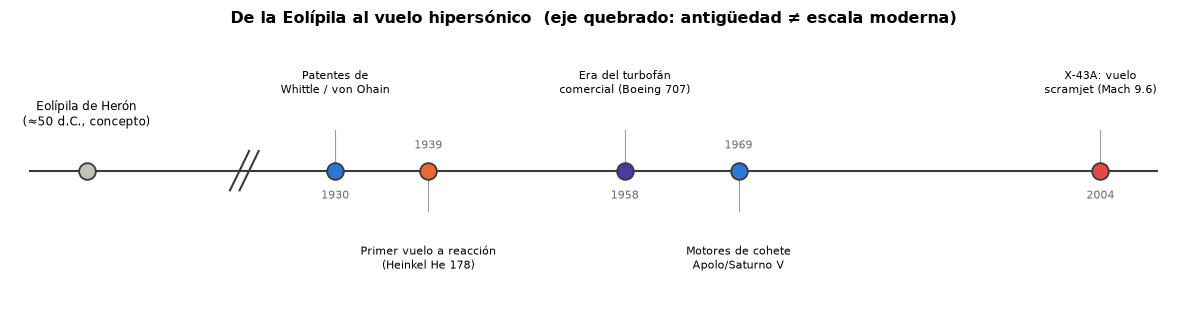

In [5]:
# Línea de tiempo histórica (complementa la narrativa de §11a, generada por código)
# Eje quebrado: ~2000 años de diferencia entre el concepto antiguo y el desarrollo
# moderno harían ilegible una escala lineal única -- se usa una ranura comprimida
# para el hito antiguo y una escala expandida (y real, lineal en años) para 1930-2004.
hitos_antiguos = [(-1.0, "Eolípila de Herón\n(≈50 d.C., concepto)", COL["metal"])]
hitos_modernos = [
    (1930, "Patentes de\nWhittle / von Ohain", COL["compresor"]),
    (1939, "Primer vuelo a reacción\n(Heinkel He 178)", COL["combustion"]),
    (1958, "Era del turbofán\ncomercial (Boeing 707)", COL["turbina"]),
    (1969, "Motores de cohete\nApolo/Saturno V", COL["aire"]),
    (2004, "X-43A: vuelo\nscramjet (Mach 9.6)", COL["perdida"]),
]

def _map_moderno(anio, a0=1930, a1=2004, x0=1.6, x1=9.6):
    return x0 + (anio-a0)/(a1-a0)*(x1-x0)

def dibujar_linea_tiempo(ax):
    ax.hlines(0, -1.6, 10.2, color=COL["tinta"], lw=1.5, zorder=1)
    # ranura de quiebre del eje (antigüedad <-> era moderna, escala no lineal)
    for dx in (-0.05, 0.05):
        ax.plot([0.55+dx, 0.75+dx], [-0.12, 0.12], color=COL["tinta"], lw=1.5, zorder=2)

    x, texto, color = hitos_antiguos[0]
    ax.plot(x, 0, "o", ms=12, color=color, mec=COL["tinta"], mew=1.3, zorder=3)
    ax.text(x, 0.25, texto, ha="center", va="bottom", fontsize=8.5)

    for k, (anio, texto, color) in enumerate(hitos_modernos):
        xm = _map_moderno(anio)
        ax.plot(xm, 0, "o", ms=12, color=color, mec=COL["tinta"], mew=1.3, zorder=3)
        arriba = k % 2 == 0
        y_txt = 0.45 if arriba else -0.45
        ax.plot([xm, xm], [0, y_txt*0.55], color=COL["tinta"], lw=0.8, alpha=0.5, zorder=2)
        ax.text(xm, y_txt, texto, ha="center", va="bottom" if arriba else "top", fontsize=8.2)
        ax.text(xm, -0.12 if arriba else 0.12, f"{anio}", ha="center",
                va="top" if arriba else "bottom", fontsize=7.8, color=COL["tinta"], alpha=0.75)

    ax.set_xlim(-1.8, 10.4); ax.set_ylim(-0.85, 0.85); ax.axis("off")
    ax.set_title("De la Eolípila al vuelo hipersónico  (eje quebrado: antigüedad ≠ escala moderna)",
                 fontsize=11.5, fontweight="bold")

fig, ax = plt.subplots(figsize=(12, 3.3))
dibujar_linea_tiempo(ax)
plt.tight_layout(); plt.show()

## 12. Modelos matemáticos

**a. Modelo térmico:**

Se basa en las leyes de la termodinámica y se utiliza para analizar y diseñar sistemas de turbinas de gas.

- **Ciclo Brayton:** Es el principio fundamental detrás de la turbina de gas. Consiste en tres procesos principales:
  1. **Compresión:** El aire es aspirado y comprimido por el compresor.
  2. **Combustión:** El aire comprimido se mezcla con el combustible en la cámara de combustión y se quema, liberando energía térmica.
  3. **Expansión:** Los gases calientes se expanden a través de la turbina, convirtiendo la energía térmica en energía mecánica.

Como en la Lección 2, cada estado se resuelve con propiedades reales de CoolProp (aire), pero aquí el compresor y la turbina **no son isentrópicos**: cada uno tiene una eficiencia propia que mide qué tan lejos está del ideal.

$$\eta_c=\frac{h_{2s}-h_1}{h_2-h_1}, \qquad \eta_t=\frac{h_3-h_4}{h_3-h_{4s}}$$

donde el subíndice $s$ marca el estado **isentrópico** (ideal) y sin subíndice el estado **real**. El trabajo neto, el calor de entrada, la eficiencia térmica y la relación de trabajo de retroceso (*back-work ratio*, la fracción del trabajo de turbina que se reinvierte en mover el compresor) quedan:

$$w_{net}=(h_3-h_4)-(h_2-h_1), \qquad q_{in}=h_3-h_2, \qquad \eta_{th}=\frac{w_{net}}{q_{in}}, \qquad BWR=\frac{h_2-h_1}{h_3-h_4}$$

In [6]:
# Ciclo Brayton real: compresor y turbina con eficiencia isentrópica (CoolProp, aire)
def ciclo_brayton_real(rp=10.0, T3=1400.0, eta_c=0.85, eta_t=0.90, T1=T_atm, P1=P_atm):
    h1 = PropsSI("H", "T", T1, "P", P1, "Air"); s1 = PropsSI("S", "T", T1, "P", P1, "Air")
    P2 = rp*P1
    h2s = PropsSI("H", "P", P2, "S", s1, "Air")
    h2 = h1 + (h2s - h1)/eta_c
    T2 = PropsSI("T", "P", P2, "H", h2, "Air")

    h3 = PropsSI("H", "T", T3, "P", P2, "Air"); s3 = PropsSI("S", "T", T3, "P", P2, "Air")
    P4 = P1
    h4s = PropsSI("H", "P", P4, "S", s3, "Air")
    h4 = h3 - eta_t*(h3 - h4s)
    T4 = PropsSI("T", "P", P4, "H", h4, "Air")

    w_comp, w_turb = h2-h1, h3-h4
    w_net, q_in = w_turb-w_comp, h3-h2
    eta_th = w_net/q_in
    BWR = w_comp/w_turb
    return dict(h1=h1,h2=h2,h3=h3,h4=h4, T1=T1,T2=T2,T3=T3,T4=T4, s1=s1,s3=s3,
                P1=P1,P2=P2, w_comp=w_comp, w_turb=w_turb, w_net=w_net, q_in=q_in,
                eta_th=eta_th, BWR=BWR)

def isobara_T_s(P, T_ini, T_fin, n=60):
    Ts = np.linspace(T_ini, T_fin, n)
    ss = np.array([PropsSI("S", "T", T, "P", P, "Air") for T in Ts])
    return ss, Ts

c0 = ciclo_brayton_real()
print(f"η_th={c0['eta_th']:.4f}  BWR={c0['BWR']:.4f}  w_net={c0['w_net']/1e3:.1f} kJ/kg")

η_th=0.3512  BWR=0.4973  w_net=320.1 kJ/kg


### Widget 2 — Ciclo Brayton real

Compara el ciclo real (línea sólida, con pérdidas en compresor y turbina) contra el ideal (línea punteada) en un diagrama T-s.

In [7]:
# WIDGET 2 — ciclo Brayton real: r_p, T3, eta_c, eta_t
def widget_brayton(rp=10.0, T3=1400.0, eta_c=0.85, eta_t=0.90):
    c = ciclo_brayton_real(rp, T3, eta_c, eta_t)
    s1s, T1s = isobara_T_s(c["P1"], 280, max(c["T1"], c["T4"])+50)
    s2s, T2s = isobara_T_s(c["P2"], 280, c["T3"]+50)

    fig, ax = plt.subplots(figsize=(7, 5.2))
    ax.plot(s1s, T1s, color=COL["aire"], lw=1, alpha=0.4)
    ax.plot(s2s, T2s, color=COL["combustion"], lw=1, alpha=0.4)

    s2s_ideal = c["s1"]
    s4s_ideal = c["s3"]
    T2s_ideal = PropsSI("T", "P", c["P2"], "S", s2s_ideal, "Air")
    T4s_ideal = PropsSI("T", "P", c["P1"], "S", s4s_ideal, "Air")
    s2_real = PropsSI("S", "H", c["h2"], "P", c["P2"], "Air")
    s4_real = PropsSI("S", "H", c["h4"], "P", c["P1"], "Air")

    # ciclo ideal (punteado)
    ax.plot([c["s1"], s2s_ideal, c["s3"], s4s_ideal, c["s1"]],
            [c["T1"], T2s_ideal, c["T3"], T4s_ideal, c["T1"]],
            "--", color=COL["tinta"], lw=1.3, alpha=0.6, label="ideal")
    # ciclo real (solido)
    ax.plot([c["s1"], s2_real, c["s3"], s4_real, c["s1"]],
            [c["T1"], c["T2"], c["T3"], c["T4"], c["T1"]],
            "-o", color=COL["turbina"], lw=2.2, ms=5, label="real")

    for x, y, lbl in [(c["s1"],c["T1"],"1"), (s2_real,c["T2"],"2"), (c["s3"],c["T3"],"3"), (s4_real,c["T4"],"4")]:
        ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(6,6), fontweight="bold")

    ax.set_xlabel("s [J/(kg·K)]"); ax.set_ylabel("T [K]")
    ax.set_title(f"$\\eta_{{th}}$={c['eta_th']*100:.1f}%   BWR={c['BWR']:.2f}   "
                 f"$w_{{net}}$={c['w_net']/1e3:.0f} kJ/kg")
    ax.legend(loc="upper left"); ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()

rp_sl = FloatSlider(10.0, min=4.0, max=30.0, step=1.0, description="$r_p$")
T3_sl = FloatSlider(1400, min=900, max=1800, step=25, description="$T_3$ [K]")
ec_sl = FloatSlider(0.85, min=0.70, max=1.00, step=0.01, description="$\\eta_c$")
et_sl = FloatSlider(0.90, min=0.70, max=1.00, step=0.01, description="$\\eta_t$")
out_brayton = interactive_output(widget_brayton, {"rp": rp_sl, "T3": T3_sl, "eta_c": ec_sl, "eta_t": et_sl})
display(VBox([HBox([rp_sl, T3_sl]), HBox([ec_sl, et_sl]), out_brayton]))

**b. Modelo de fluidos:**

Se refiere a la aerodinámica y la mecánica de fluidos involucradas en la operación de la turbina de gas. Estudia cómo se mueven los gases a través del motor, cómo interactúan con las palas de la turbina y cómo se comportan bajo diferentes condiciones.

El empuje de un motor a reacción se trata con una descripción de "caja negra" que solo observa lo que entra en el motor a reacción, aire y combustible, y lo que sale, gas de escape y una fuerza desequilibrada. Esta fuerza, llamada empuje, es la suma de la diferencia de momento entre la entrada y la salida y cualquier fuerza de presión desequilibrada entre la entrada y la salida.

- **Fórmula de cálculo de empuje:** El empuje neto ($F_N$) de un motor se da por:

$$F_N=(\dot m_{aire}+\dot m_{combustible})\,v_e-\dot m_{aire}\,v$$

| Variable | Significado | Unidad |
|---|---|---|
| $\dot m_{aire}$ | flujo másico de aire a través del motor | kg/s |
| $\dot m_{combustible}$ | flujo másico de combustible inyectado | kg/s |
| $v_e$ | velocidad efectiva de escape del chorro | m/s |
| $v$ | velocidad de vuelo (velocidad del aire a la entrada) | m/s |

**Ejemplo numérico:** un turbofán en crucero con $\dot m_{aire}=90$ kg/s, $\dot m_{combustible}=0.9$ kg/s, $v_e=380$ m/s y $v=230$ m/s produce $F_N=(90+0.9)(380)-90(230)=34{,}542-20{,}700\approx\mathbf{13{,}842\ N}\approx 13.8$ kN.

In [8]:
# WIDGET 3 — empuje neto F_N, diagrama de caja negra
def widget_empuje(mdot_aire=90.0, mdot_comb=0.9, ve=380.0, v=230.0):
    FN = (mdot_aire + mdot_comb)*ve - mdot_aire*v
    empuje_esp = FN/mdot_aire

    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.add_patch(Rectangle((1.5, 0), 2.0, 1.4, fc=COL["compresor"], ec=COL["tinta"], lw=1.5, alpha=0.85))
    ax.text(2.5, 0.7, "MOTOR\n(caja negra)", ha="center", va="center", color="white", fontweight="bold")

    ax.add_patch(FancyArrowPatch((0.0, 1.0), (1.5, 1.0), arrowstyle="-|>", mutation_scale=16,
                                  color=COL["aire"], lw=2.2))
    ax.text(0.7, 1.15, f"$\\dot m_{{aire}}$={mdot_aire:.0f} kg/s\n$v$={v:.0f} m/s", fontsize=8, ha="center")

    ax.add_patch(FancyArrowPatch((0.3, 0.3), (1.5, 0.3), arrowstyle="-|>", mutation_scale=12,
                                  color=COL["combustion"], lw=1.6))
    ax.text(0.9, 0.05, f"$\\dot m_{{comb}}$={mdot_comb:.2f} kg/s", fontsize=7.5, ha="center")

    ax.add_patch(FancyArrowPatch((3.5, 0.7), (5.3, 0.7), arrowstyle="-|>", mutation_scale=18,
                                  color=COL["perdida"], lw=2.6))
    ax.text(4.4, 0.95, f"$v_e$={ve:.0f} m/s", fontsize=8.5, ha="center", fontweight="bold")

    ax.annotate("", xy=(5.6, -0.35), xytext=(3.5, -0.35),
                arrowprops=dict(arrowstyle="-|>", color=COL["tinta"], lw=2))
    ax.text(4.55, -0.55, f"$F_N$ = {FN/1e3:.2f} kN", ha="center", fontsize=10, fontweight="bold")

    ax.set_xlim(-0.3, 6.0); ax.set_ylim(-0.9, 1.6); ax.axis("off")
    ax.set_title(f"empuje específico $F_N/\\dot m_{{aire}}$ = {empuje_esp:.1f} N·s/kg")
    plt.tight_layout(); plt.show()

ma_sl = FloatSlider(90, min=10, max=300, step=5, description="$\\dot m_{aire}$ [kg/s]")
mc_sl = FloatSlider(0.9, min=0.1, max=5.0, step=0.1, description="$\\dot m_{comb}$ [kg/s]")
ve_sl2 = FloatSlider(380, min=100, max=1500, step=10, description="$v_e$ [m/s]")
v_sl2 = FloatSlider(230, min=0, max=900, step=10, description="$v$ [m/s]")
out_empuje = interactive_output(widget_empuje, {"mdot_aire": ma_sl, "mdot_comb": mc_sl, "ve": ve_sl2, "v": v_sl2})
display(VBox([HBox([ma_sl, mc_sl]), HBox([ve_sl2, v_sl2]), out_empuje]))

**c. Operación:**

- **Funcionamiento estable:** Se refiere a cuando el motor opera en condiciones constantes, como durante un vuelo de crucero. En este estado, el flujo de aire, la combustión y la expansión ocurren a tasas constantes.

- **Transitorios:** Son los cambios en las condiciones de operación, como durante el despegue, el ascenso, el descenso o el aterrizaje. Durante estos periodos, el motor debe adaptarse a diferentes demandas de empuje y condiciones operativas.

**d. Eficiencia:**

La eficiencia de una turbina de gas se refiere a cuánta energía útil se obtiene del combustible quemado. Se puede mejorar mediante varios métodos, como aumentar la relación de compresión o utilizar tecnologías de enfriamiento avanzadas.

- **Eficiencia térmica** ($\eta_{th}$, §12a): cuánta de la energía del combustible se convierte en trabajo/energía cinética del chorro.
- **Eficiencia propulsiva:** cuán eficientemente esa energía cinética del chorro se convierte en trabajo útil sobre el avión. Depende de factores como la velocidad del avión, la velocidad del chorro de escape y la altitud:

$$\eta_{prop}=\frac{F_N\,v}{\tfrac12\dot m_{aire}(v_e^2-v^2)}=\frac{2v}{v+v_e}=\frac{2}{1+v_e/v}$$

- **Eficiencia total:** es el producto de la eficiencia térmica y la eficiencia propulsiva. Representa la eficiencia global del motor en términos de conversión de energía del combustible en empuje útil:

$$\eta_o=\eta_{th}\cdot\eta_{prop}$$

- **Optimización:** Los fabricantes de motores trabajan constantemente para mejorar la eficiencia de los motores a reacción mediante la investigación y el desarrollo de nuevas tecnologías, materiales y diseños.

Con estos modelos y principios, los ingenieros pueden diseñar y optimizar motores a reacción para diversas aplicaciones, desde aviones comerciales hasta vehículos espaciales.

> **La paradoja de $\eta_{prop}$:** cuando $v\to v_e$ (el chorro apenas se mueve más rápido que el avión), $\eta_{prop}\to 1$ — pero $F_N=\dot m(v_e-v)\to 0$. Máxima eficiencia propulsiva y empuje útil nulo ocurren en el mismo límite: por eso ningún motor real opera ahí, y cada arquitectura (§3-§9) elige su propio compromiso $v_e/v$ según el régimen de velocidad para el que fue diseñada — el **Widget 4** lo muestra cuantitativamente.

In [9]:
# WIDGET 4 — eficiencia propulsiva vs. velocidad de vuelo, por arquitectura (ve típica de cada una)
a_sonido = 295.0  # m/s, aprox a 10-11 km de altitud de crucero

ve_tipicas = {
    "Turbohélice (§4)": (150, COL["helice"]),
    "Turbofán (§5)": (400, COL["compresor"]),
    "Turborreactor (§6)": (600, COL["turbina"]),
    "Ramjet (§7)": (1100, COL["combustion"]),
}

def widget_eta_prop(v_vuelo=100.0):
    # La fórmula eta_prop=2v/(v+ve) solo tiene sentido físico para v<v_e (empuje neto
    # positivo, F=mdot(ve-v)>0); más allá de v=ve el "motor" estaría frenando, no
    # propulsando -- cada curva se recorta en su propio v_e.
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.3))

    for nombre, (ve, color) in ve_tipicas.items():
        v_arr = np.linspace(5, ve*0.995, 250)
        eta_p = 2.0/(1.0 + ve/v_arr)
        ax0.plot(v_arr/a_sonido, eta_p, color=color, lw=2, label=f"{nombre}  ($v_e$={ve} m/s)")
    ax0.axvline(v_vuelo/a_sonido, color=COL["tinta"], ls="--", lw=1)
    ax0.set_xlabel("Mach de vuelo"); ax0.set_ylabel("$\\eta_{prop}$")
    ax0.set_ylim(0, 1.05); ax0.set_xlim(0, 1100/a_sonido)
    ax0.set_title("Eficiencia propulsiva por arquitectura\n(cada curva termina en su propio $v=v_e$)")
    ax0.legend(fontsize=7.5, loc="lower right"); ax0.grid(alpha=0.25)
    ax0.spines[["top", "right"]].set_visible(False)

    nombres, etas, colores, validos = [], [], [], []
    for nombre, (ve, color) in ve_tipicas.items():
        nombres.append(nombre); colores.append(color)
        if v_vuelo < ve:
            etas.append(2.0/(1.0 + ve/v_vuelo)); validos.append(True)
        else:
            etas.append(0.0); validos.append(False)  # v >= v_e: fuera del régimen de esta arquitectura
    barras = ax1.bar(nombres, etas, color=[c if ok else COL["cerrada"] for c, ok in zip(colores, validos)],
                      ec=COL["tinta"], lw=1.2)
    for b, e, ok in zip(barras, etas, validos):
        txt = f"{e*100:.0f}%" if ok else "v≥$v_e$\n(no aplica)"
        b.set_alpha(1.0 if ok else 0.35)
        ax1.text(b.get_x()+b.get_width()/2, (e if ok else 0.03)+0.02, txt, ha="center",
                  fontsize=8.5 if ok else 7.5, fontweight="bold" if ok else "normal")
    ax1.set_ylim(0, 1.05); ax1.set_ylabel("$\\eta_{prop}$")
    ax1.set_title(f"a Mach {v_vuelo/a_sonido:.2f}  (v={v_vuelo:.0f} m/s)")
    plt.setp(ax1.get_xticklabels(), rotation=20, ha="right", fontsize=8)
    ax1.grid(axis="y", alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)

    plt.tight_layout(); plt.show()

v_sl3 = FloatSlider(100, min=20, max=1050, step=10, description="v vuelo [m/s]")
out_eta = interactive_output(widget_eta_prop, {"v_vuelo": v_sl3})
display(VBox([v_sl3, out_eta]))

## Verificación

Cuatro chequeos independientes, cada uno con su naturaleza declarada:

1. **Ciclo Brayton real → ideal** (CoolProp, aire real con $c_p$ variable) vs. **fórmula clásica de aire frío estándar** $\eta_{th}=1-r_p^{-(k-1)/k}$, en el límite de bajo salto térmico (donde ambos modelos deben coincidir).
2. **Límite analítico de $\eta_{prop}$:** cuando $v=v_e$, la fórmula debe dar exactamente $\eta_{prop}=1$.
3. **Balance de energía del chorro:** potencia propulsiva útil + potencia perdida en la estela = potencia cinética total añadida al aire.
4. **Consistencia $F=\dot m\,g_0\,I_{sp}$** vs. $F=\dot m\,v_e$ (identidad de la definición de impulso específico).

In [10]:
# === Verificación ===========================================================
errores = []

# 1) Brayton real (CoolProp) vs. fórmula clásica de aire frío estándar, bajo salto térmico
rp_v, T3_v = 2.0, 310.0
c = ciclo_brayton_real(rp=rp_v, T3=T3_v, eta_c=1.0, eta_t=1.0)
k_ref = PropsSI("Cpmass", "T", T_atm, "P", P_atm, "Air")/PropsSI("Cvmass", "T", T_atm, "P", P_atm, "Air")
eta_formula = 1 - rp_v**(-(k_ref-1)/k_ref)
err1 = 100*abs(c["eta_th"] - eta_formula)/eta_formula
errores.append(err1)
print(f"1) η_th CoolProp (bajo ΔT) = {c['eta_th']:.4f}   fórmula clásica = {eta_formula:.4f}   (err {err1:.3f} %)")

# 2) eta_prop -> 1 cuando v=ve
ve_t, v_t = 400.0, 400.0
eta_p = 2.0/(1.0 + ve_t/v_t)
err2 = 100*abs(eta_p - 1.0)
errores.append(err2)
print(f"2) η_prop(v=v_e) = {eta_p:.6f}  (referencia teórica = 1;  err {err2:.4f} %)")

# 3) balance de energía del chorro
mdot_t, ve3, v3 = 50.0, 500.0, 200.0
FN_t = mdot_t*(ve3 - v3)
P_util = FN_t*v3
P_estela = 0.5*mdot_t*(ve3 - v3)**2
P_total = 0.5*mdot_t*(ve3**2 - v3**2)
err3 = 100*abs((P_util + P_estela) - P_total)/P_total
errores.append(err3)
print(f"3) P_útil+P_estela = {P_util+P_estela:.1f} W   P_total = {P_total:.1f} W   (err {err3:.6f} %)")

# 4) F = mdot*g0*Isp vs F = mdot*ve
ve4, mdot4 = 3000.0, 10.0
Isp4 = ve4/g0
F_a = mdot4*ve4
F_b = mdot4*g0*Isp4
err4 = 100*abs(F_a - F_b)/F_a
errores.append(err4)
print(f"4) F (mdot·v_e) = {F_a:.1f} N   F (mdot·g0·Isp) = {F_b:.1f} N   (err {err4:.2e} %)")

print(f"\n✔ Verificación superada (máx. {max(errores):.4f} % < 1 %)" if max(errores) < 1
      else f"\n✘ Revisar: máx. error = {max(errores):.4f} %")

1) η_th CoolProp (bajo ΔT) = 0.1798   fórmula clásica = 0.1803   (err 0.271 %)
2) η_prop(v=v_e) = 1.000000  (referencia teórica = 1;  err 0.0000 %)
3) P_útil+P_estela = 5250000.0 W   P_total = 5250000.0 W   (err 0.000000 %)
4) F (mdot·v_e) = 30000.0 N   F (mdot·g0·Isp) = 30000.0 N   (err 1.21e-14 %)

✔ Verificación superada (máx. 0.2709 % < 1 %)
